# Phase 5: Robustness & Insight

**Goal:** Two analyses that go beyond point-estimate evaluation.

**Part A: Bootstrap CI for Qini AUC:** Phase 4 reported T-Learner Qini AUC = 0.0380 and X-Learner = 0.0760 on a single test set. This part asks whether that gap is robust or within sampling noise. The test set is resampled 500 times (stratified bootstrap), computing Qini AUC on each resample to produce a 95% confidence interval for both models.

**Part B: Persuadables Profiling:** Identifies what distinguishes users the model ranks as high-uplift (top 10%) from those it ranks as low-uplift (bottom 10%). Compares feature distributions across both groups and quantifies separation with the KS statistic.

**Inputs:** `data/tlearner_scores.parquet`, `data/xlearner_scores.parquet`, `data/df_sample.parquet`  
**Outputs:** `data/scores_combined.parquet`, `images/qini_bootstrap_ci.png`, `images/persuadables_profile.png`

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from scipy.stats import ks_2samp
from sklift.metrics import qini_auc_score
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)


%matplotlib inline
sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.max_columns", None)

## 2. Load Scores

Load both score files and verify they are row-aligned before combining. Both files share the same `y_true` and `treatment` columns because they were produced from the same `train_test_split(random_state=1)`. The assert checks confirm this. The combined `df` has four columns: `y_true`, `treatment`, `uplift_t`, `uplift_x`. Saving it avoids repeating this step in later notebooks.

In [2]:
df_t = pd.read_parquet("../data/tlearner_scores.parquet")
df_x = pd.read_parquet("../data/xlearner_scores.parquet")

print("T-Learner scores:", df_t.shape)
print("X-Learner scores:", df_x.shape)
df_t.head()

T-Learner scores: (279592, 3)
X-Learner scores: (279592, 3)


,uplift,y_true,treatment
0,-0.010524,0,0
1,-0.000288,0,0
2,-0.020646,0,1
3,0.013442,0,1
4,0.141881,0,1


In [3]:
assert df_t["y_true"].equals(df_x["y_true"]), "y_true mismatch"
assert df_t["treatment"].equals(df_x["treatment"]), "treatment mismatch"

df = df_t[["y_true", "treatment"]].copy()
df["uplift_t"] = df_t["uplift"].values
df["uplift_x"] = df_x["uplift"].values

In [4]:
df.to_parquet("../data/scores_combined.parquet", index=False)
print("Saved: data/scores_combined.parquet")
print(df.shape)
df.head()

Saved: data/scores_combined.parquet
(279592, 4)


,y_true,treatment,uplift_t,uplift_x
0,0,0,-0.010524,0.153837
1,0,0,-0.000288,0.086222
2,0,1,-0.020646,0.046369
3,0,1,0.013442,0.062421
4,0,1,0.141881,0.162168


## Part A: Bootstrap Confidence Intervals

## 3. Bootstrap Sampling

Resample the test set 500 times with replacement. Treatment and control rows are sampled independently to preserve the 85/15 ratio in every iteration. Both models are evaluated on the same resample since `uplift_t` and `uplift_x` live in the same combined `df`.

In [5]:
n_bootstrap = 500

treated = df[df["treatment"] == 1]
control = df[df["treatment"] == 0]

auc_t_boot = []
auc_x_boot = []

for i in range(n_bootstrap):
    sample = pd.concat([
        treated.sample(n=len(treated), replace=True, random_state=i),
        control.sample(n=len(control), replace=True, random_state=i),
    ])
    auc_t_boot.append(qini_auc_score(sample["y_true"], sample["uplift_t"], sample["treatment"]))
    auc_x_boot.append(qini_auc_score(sample["y_true"], sample["uplift_x"], sample["treatment"]))

auc_t_boot = np.array(auc_t_boot)
auc_x_boot = np.array(auc_x_boot)
print("Bootstrap complete.")

Bootstrap complete.


## 4. Confidence Interval & Visualization

Compute 95% CI (2.5th and 97.5th percentiles) from the bootstrap distribution.  
Plot overlapping histograms of Qini AUC for both models with CI bounds marked as dashed vertical lines.

T-Learner: 0.0388  95% CI [0.0225, 0.0537]
X-Learner: 0.0755  95% CI [0.0572, 0.0954]


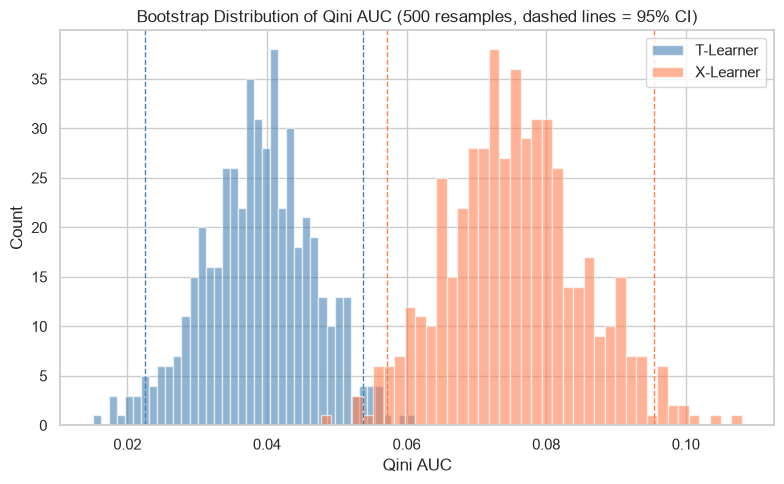

In [6]:
ci_t = (np.percentile(auc_t_boot, 2.5), np.percentile(auc_t_boot, 97.5))
ci_x = (np.percentile(auc_x_boot, 2.5), np.percentile(auc_x_boot, 97.5))

print(f"T-Learner: {auc_t_boot.mean():.4f}  95% CI [{ci_t[0]:.4f}, {ci_t[1]:.4f}]")
print(f"X-Learner: {auc_x_boot.mean():.4f}  95% CI [{ci_x[0]:.4f}, {ci_x[1]:.4f}]")

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(auc_t_boot, bins=40, alpha=0.6, color="steelblue", label="T-Learner")
ax.hist(auc_x_boot, bins=40, alpha=0.6, color="coral", label="X-Learner")

for val in ci_t:
    ax.axvline(val, color="steelblue", linestyle="--", linewidth=1)
for val in ci_x:
    ax.axvline(val, color="coral", linestyle="--", linewidth=1)

ax.set_xlabel("Qini AUC")
ax.set_ylabel("Count")
ax.set_title("Bootstrap Distribution of Qini AUC (500 resamples, dashed lines = 95% CI)")
ax.legend()
plt.tight_layout()
plt.savefig("../images/qini_bootstrap_ci.png", dpi=150, bbox_inches="tight")
plt.show()

The two distributions do not overlap: T-Learner's upper bound (0.0537) sits below X-Learner's lower bound (0.0572). The X-Learner advantage is robust, not a product of test set luck. Both histograms appear as roughly symmetric bell curves, consistent with CLT applying to a mean-like statistic computed over 279K rows per resample.

## Part B: Persuadables Profiling

## 5. Define Persuadables vs Low-Uplift Users

Using X-Learner scores, rank all test users by predicted uplift. Take the top 10% as persuadables and the bottom 10% as the low-uplift group. Load original features (f0-f11) for both groups.

In [7]:
df_sample = pd.read_parquet("../data/df_sample.parquet")

features = [f"f{i}" for i in range(12)]
X = df_sample[features]
y = df_sample["visit"]
t = df_sample["treatment"]
stratify_col = y.astype("str") + "_" + t.astype("str")

X_train, X_test, y_train, y_test, t_train, t_test = train_test_split(
    X, y, t,
    test_size=0.2,
    random_state=1,
    stratify=stratify_col
)

# verify the re-run split matches the saved scores
assert (y_test.values == df["y_true"].values).all(), "y_true mismatch"
assert (t_test.values == df["treatment"].values).all(), "treatment mismatch"

X_test = X_test.copy()
X_test["uplift_x"] = df["uplift_x"].values

n = int(0.1 * len(X_test))
persuadables = X_test.nlargest(n, "uplift_x")[features]
low_uplift = X_test.nsmallest(n, "uplift_x")[features]

print(f"Persuadables:  {len(persuadables):,} users (top 10% by predicted uplift)")
print(f"Low-uplift:    {len(low_uplift):,} users (bottom 10% by predicted uplift)")

Persuadables:  27,959 users (top 10% by predicted uplift)
Low-uplift:    27,959 users (bottom 10% by predicted uplift)


## 6. Feature Distributions

Plot overlaid density distributions for each of the 12 features, comparing persuadables vs low-uplift users. Features with the largest visual separation are the strongest signals.

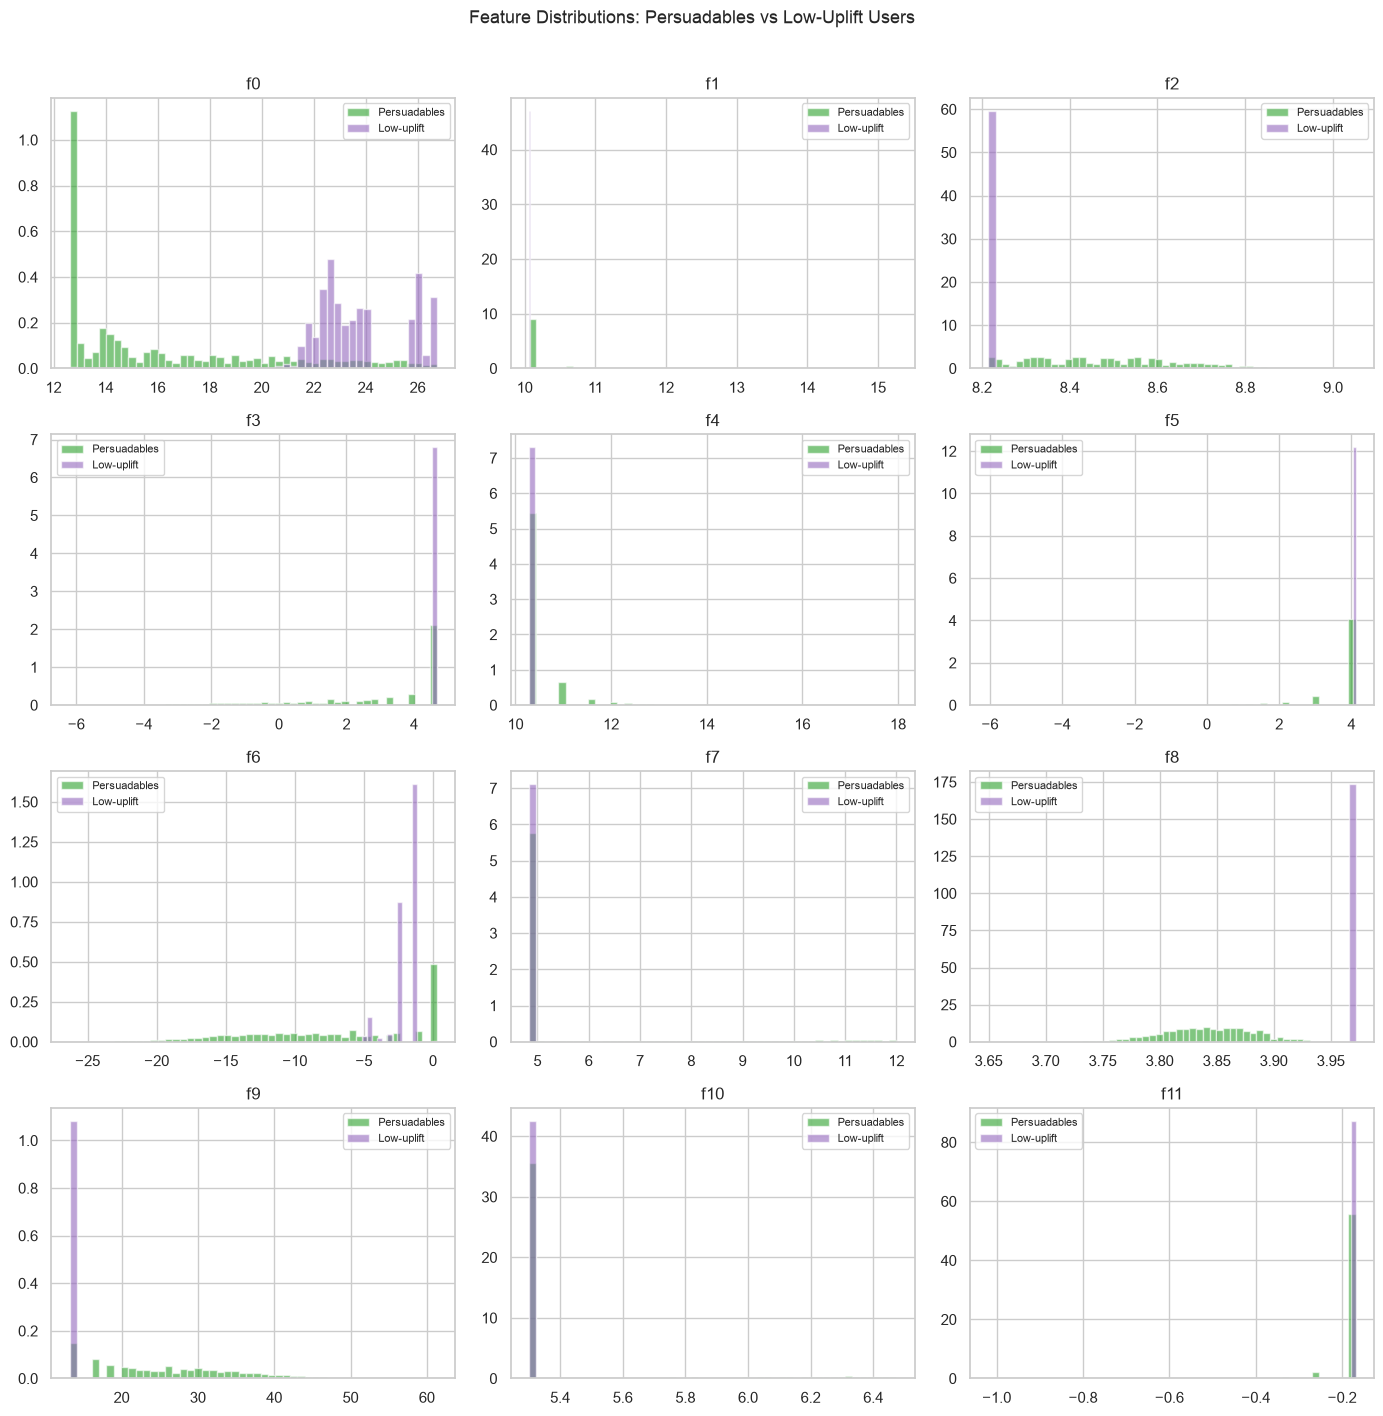

In [8]:
fig, axes = plt.subplots(4, 3, figsize=(14, 14))
axes = axes.flatten()

for i, feat in enumerate(features):
    axes[i].hist(persuadables[feat].dropna(), bins=50, alpha=0.6, color="tab:green", density=True, label="Persuadables")
    axes[i].hist(low_uplift[feat].dropna(), bins=50, alpha=0.6, color="tab:purple", density=True, label="Low-uplift")
    axes[i].set_title(feat)
    axes[i].set_xlabel("")
    axes[i].legend(fontsize=8)

plt.suptitle("Feature Distributions: Persuadables vs Low-Uplift Users", y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig("../images/persuadables_profile.png", dpi=150, bbox_inches="tight")
plt.show()

Five features show strong visual separation between persuadables and low-uplift users: f8, f2, f9, f0, and f6. f2 and f9 shift persuadables toward higher values; f0, f6, and f8 show the opposite pattern where low-uplift users cluster at higher values while persuadables spread toward lower values. f2 is the most visually striking: both groups occupy opposite ends of a narrow range (8.2 to 9.0). f3 has moderate separation. f1 appears uniform for low-uplift users with no visible purple bar; this is explained by clipping (see note below).

In [9]:
print(persuadables["f1"].describe())
print(low_uplift["f1"].describe())

count    27959.000000
mean        10.117737
std          0.247990
min         10.059654
25%         10.059654
50%         10.059654
75%         10.059654
max         15.259263
Name: f1, dtype: float64
count    27959.000000
mean        10.060411
std          0.022770
min         10.059654
25%         10.059654
50%         10.059654
75%         10.059654
max         11.119309
Name: f1, dtype: float64


f1 is heavily clipped at 10.059654: at least 75% of users in both groups share this exact floor value. The purple bars are hidden in the chart because both groups produce an overlapping spike at the same bin. The only visible difference is in the right tail: persuadables extend to 15.26 (std 0.248) while low-uplift only reach 11.12 (std 0.023). This makes f1 a weak separating feature despite the visual spike.

## 7. Feature Separation Score

Quantify the separation for each feature using the KS statistic (Kolmogorov-Smirnov test). A higher KS statistic means the two groups have more distinct distributions for that feature. Rank features by KS statistic and display a summary table.

In [10]:
rows = []
for feat in features:
    stat, pval = ks_2samp(persuadables[feat].dropna(), low_uplift[feat].dropna())
    rows.append({"feature": feat, "ks_stat": round(stat, 4), "p_value": pval})

ks_df = pd.DataFrame(rows).sort_values("ks_stat", ascending=False).reset_index(drop=True)
ks_df["p_value"] = ks_df["p_value"].apply(lambda x: f"{x:.2e}")
print(ks_df.to_string(index=False))

feature  ks_stat  p_value
     f8   0.9989 0.00e+00
     f2   0.9986 0.00e+00
     f9   0.8544 0.00e+00
     f0   0.8235 0.00e+00
     f6   0.5937 0.00e+00
     f3   0.5405 0.00e+00
     f5   0.1703 0.00e+00
     f7   0.1703 0.00e+00
     f4   0.1638 0.00e+00
    f10   0.1638 0.00e+00
     f1   0.0652 4.07e-52
    f11   0.0515 1.03e-32


All 12 features are statistically significant (all p-values effectively zero), but separation strength varies widely. f8 and f2 are nearly perfectly separated (KS ~0.999). f9 and f0 follow with strong separation (0.82-0.85). f6 and f3 are moderate (0.54-0.59). The bottom 6 features (f4, f5, f7, f10, f1, f11) have KS below 0.18, contributing little signal for distinguishing persuadables.

## 8. Summary

**Part A: Bootstrap CI**

The X-Learner's 2x Qini AUC advantage (0.0760 vs 0.0380) is robust to resampling. 95% CIs from 500 stratified bootstrap resamples do not overlap: T-Learner [0.0225, 0.0537], X-Learner [0.0572, 0.0954].

**Part B: Persuadables Profiling**

6 features separate persuadables from low-uplift users with meaningful KS statistics: f8 and f2 (KS ~0.999), f9 and f0 (0.82-0.85), f6 and f3 (0.54-0.59). Persuadables score higher on f2 and f9; low-uplift users score higher on f0, f6, and f8. The remaining 6 features (KS below 0.18) contribute little targeting signal.